# 04a — Y2Y corridor-wide results

Results analysis for the corridor-wide run (`config.ANALYSES["y2y"]`), over the shared `results_core.py` engine. Benchmark = the 6 featured parks + the Ross River IPCA. **Kernel:** `.venv` (Python). Ethan runs cell-by-cell.

In [1]:
# ---- Setup: shared results engine + this analysis' key -------------------
import importlib
import results_core as rc, config
importlib.reload(config); importlib.reload(rc)

ANALYSIS = "y2y"            # <-- the ONLY line that differs between 04a / 04b / 04c
A = rc.load(ANALYSIS)          # locate the run + region label + map outline + benchmark spec
rc.load_rasters(A)             # portfolio + selection-frequency rasters

analysis=y2y | run=iter6_y2y | objective=min_shortfall | proportion/LP
region=Y2Y | figures -> output_data/iter6_y2y/figures
portfolio: 1 solution(s) | grid 1286 x 3312
allocation surface: 0.00..1.00


namespace(analysis='y2y',
          a04={'region_label': 'Y2Y',
               'cluster_select': 'spread',
               'benchmark': {'type': 'named_pa',
                'featured': [('Nahanni National Park Reserve Of Canada',
                  'Nahanni NPR'),
                 ('Spatsizi Plateau Wilderness Park', 'Spatsizi Plateau'),
                 ('Jasper National Park Of Canada', 'Jasper NP'),
                 ('Banff National Park Of Canada', 'Banff NP'),
                 ('Glacier', 'Glacier NP (MT)'),
                 ('Yellowstone National Park', 'Yellowstone NP')]},
               'benchmark_title': 'Featured protected areas',
               'manual_area': {'name': 'Ross River IPCA',
                'color': 'crimson',
                'shp': PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/input_data/y2y_ross_river/RRA_nonoverlap_3_revised.shp')},
               'outline_label': 'Y2Y boundary',
               'context_outline': None,
          

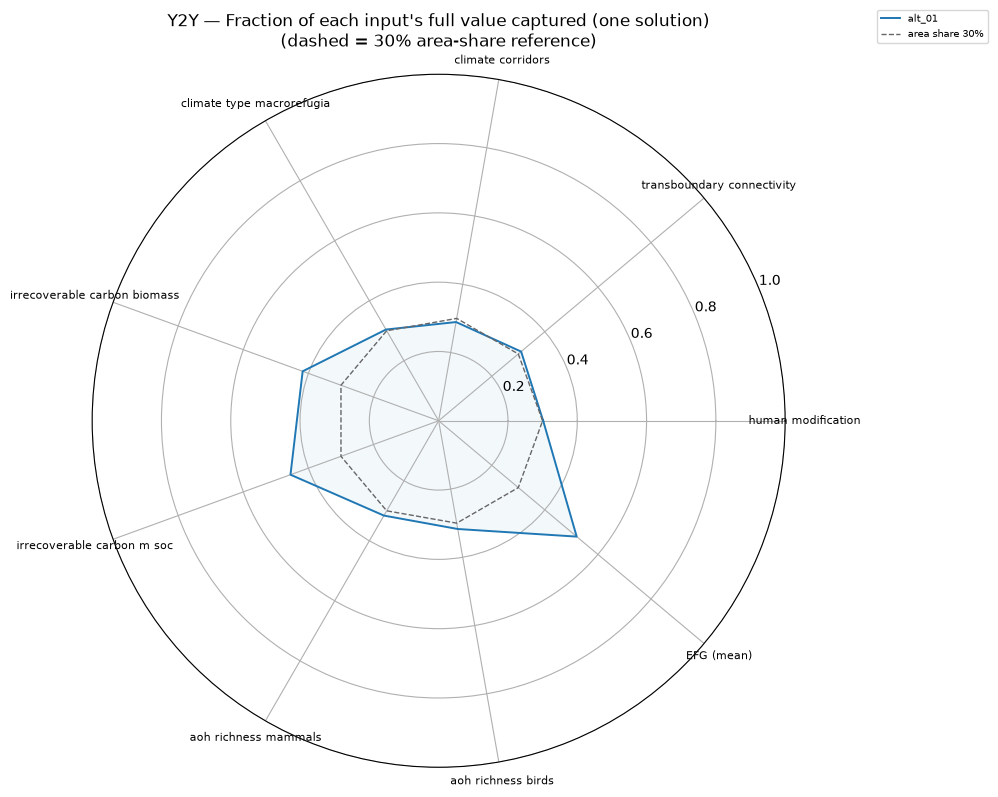

In [2]:
# ---- Radar: captured fraction per input vs the area-share ring ----
rc.radar(A)

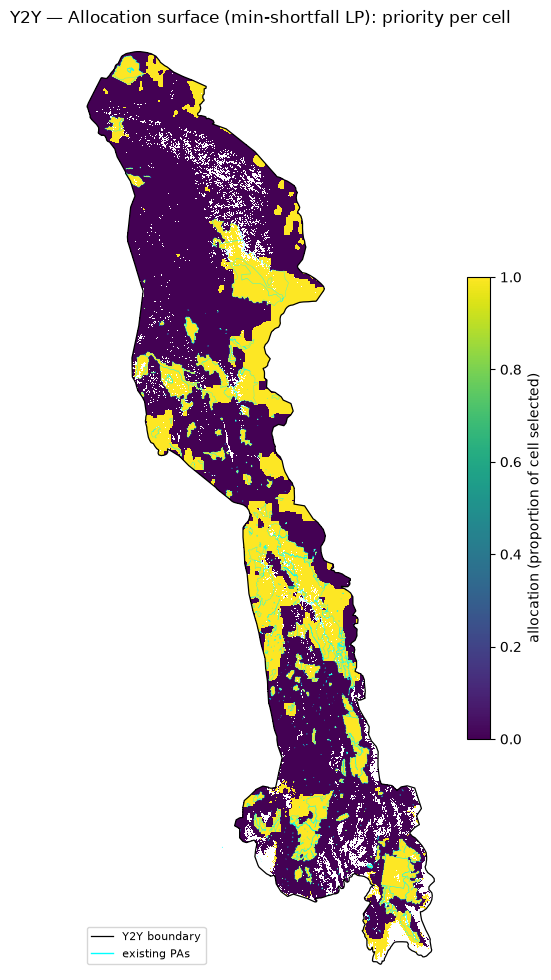

In [3]:
# ---- Allocation surface / selection-frequency map ----
rc.allocation_map(A)

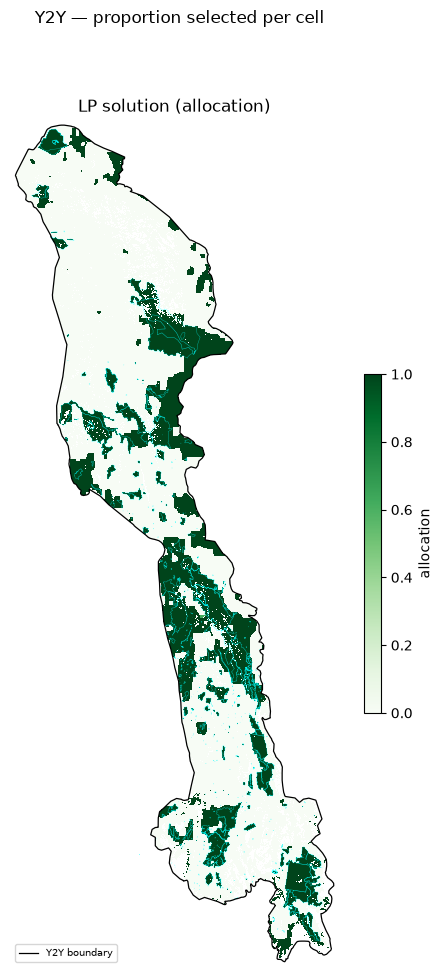

In [4]:
# ---- Solution map(s) ----
rc.solution_maps(A)

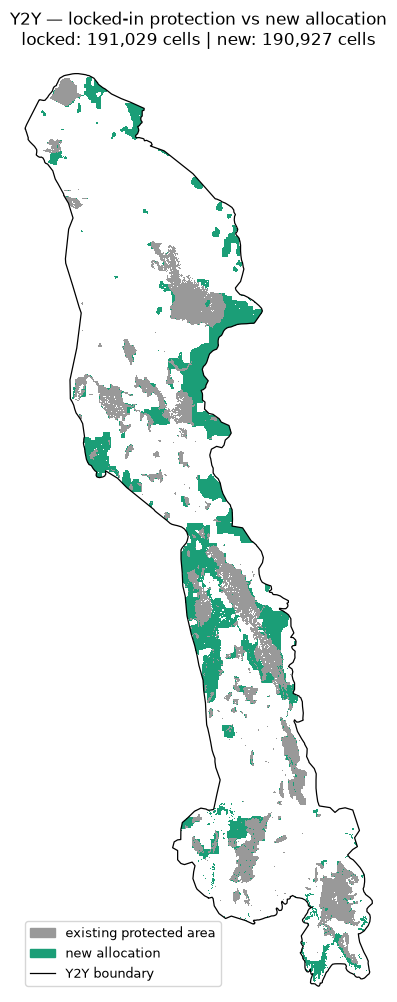

In [5]:
# ---- Existing protection vs new allocation ----
rc.existing_vs_new(A)

In [6]:
# ---- Trade-off table + headline stats ----
rc.tradeoff(A)

Per-solution summary:
alternative  n_selected  pct_region  n_added_beyond_pa
     alt_01    381874.2          30             190705

window planning units : 1,272,914
area budget (cells)   : 381,874 (30%)
locked-in             : 191,029 (15.0% of window)
area selected         : 30.0% of window


## Candidate areas vs the existing-protection benchmark

`build_stacks` loads the feature stacks, computes **full-Y2Y** region totals (so contribution / efficiency stay “% of Y2Y”), and profiles: the **NEW candidate areas** (connected blocks of new allocation) and the analysis' **benchmark** block (y2y: featured parks + Ross River; north_bc: the 4 IPCA anchors; ab_foothills: the existing in-window PAs). Each area gets three star-plot views + the consequences tables. Figures/CSVs → the run's folder.

In [7]:
# ---- Build stacks + profile NEW clusters + benchmark block (+ manual area) ----
rc.build_stacks(A)

  spread: 6 clusters over lat 42.6-66.5N
new candidate areas   : 1254 components, 6 kept (>= 25 cells, spread)
benchmark areas       : 6 profiled [named_pa]
cell size 1.0 km^2 | full-Y2Y PU denom = 1,272,914
shared efficiency scale EFF_RMAX = 0.30 %/1,000 km^2


namespace(analysis='y2y',
          a04={'region_label': 'Y2Y',
               'cluster_select': 'spread',
               'benchmark': {'type': 'named_pa',
                'featured': [('Nahanni National Park Reserve Of Canada',
                  'Nahanni NPR'),
                 ('Spatsizi Plateau Wilderness Park', 'Spatsizi Plateau'),
                 ('Jasper National Park Of Canada', 'Jasper NP'),
                 ('Banff National Park Of Canada', 'Banff NP'),
                 ('Glacier', 'Glacier NP (MT)'),
                 ('Yellowstone National Park', 'Yellowstone NP')]},
               'benchmark_title': 'Featured protected areas',
               'manual_area': {'name': 'Ross River IPCA',
                'color': 'crimson',
                'shp': PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/input_data/y2y_ross_river/RRA_nonoverlap_3_revised.shp')},
               'outline_label': 'Y2Y boundary',
               'context_outline': None,
          

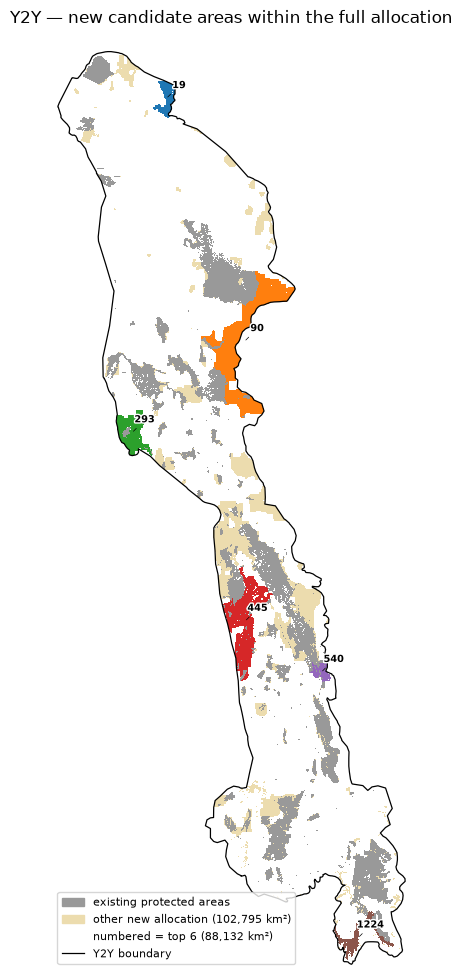

In [8]:
# ---- New candidate areas: map (colored, numbered) within the full allocation ----
rc.new_map(A)

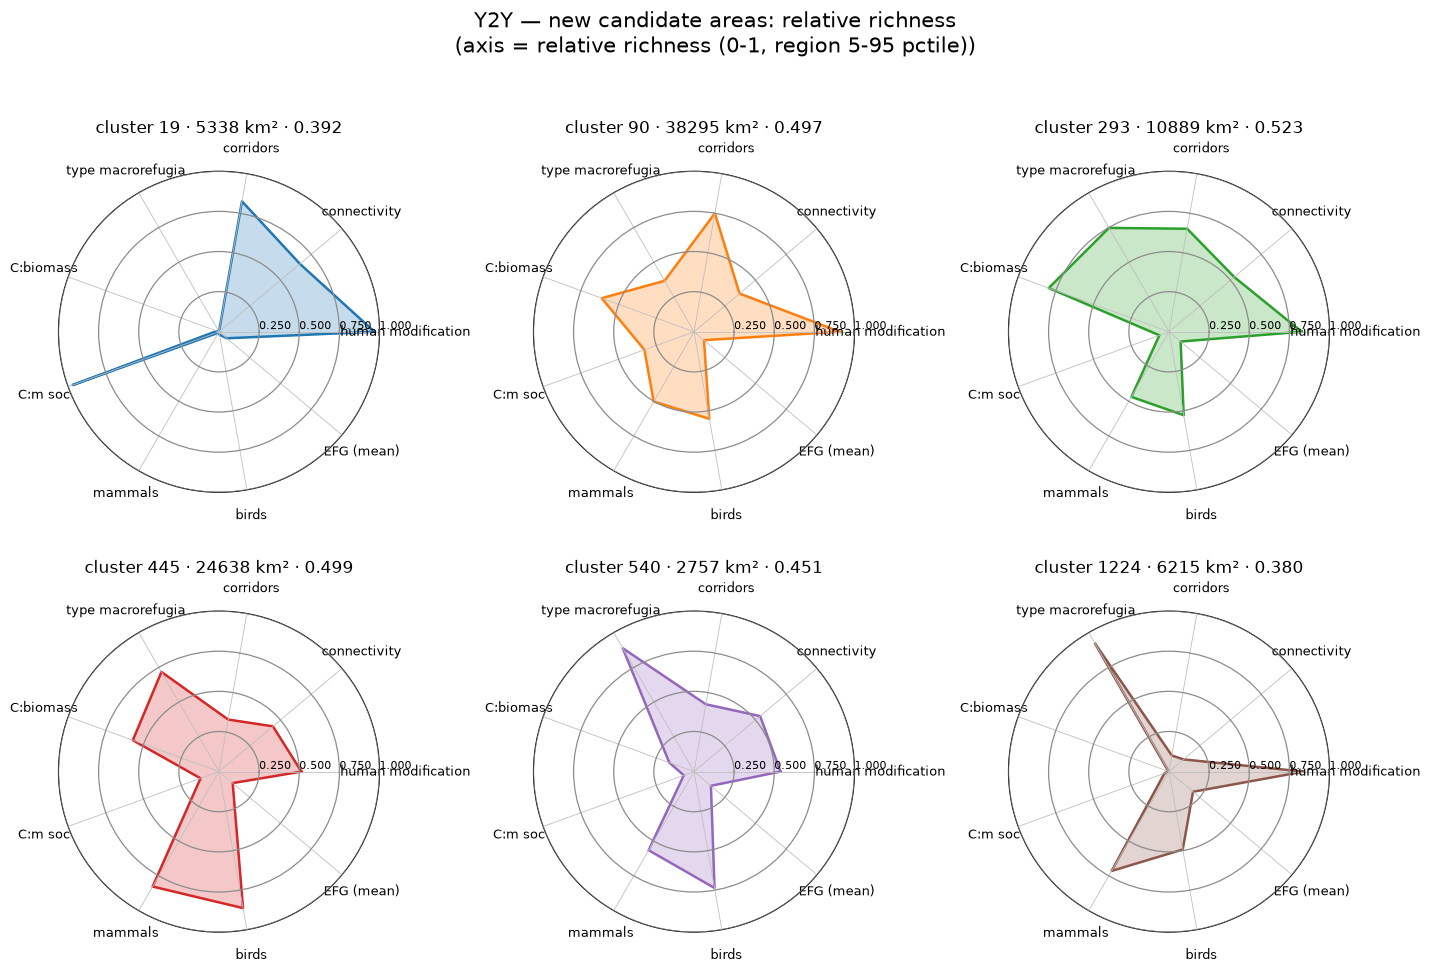

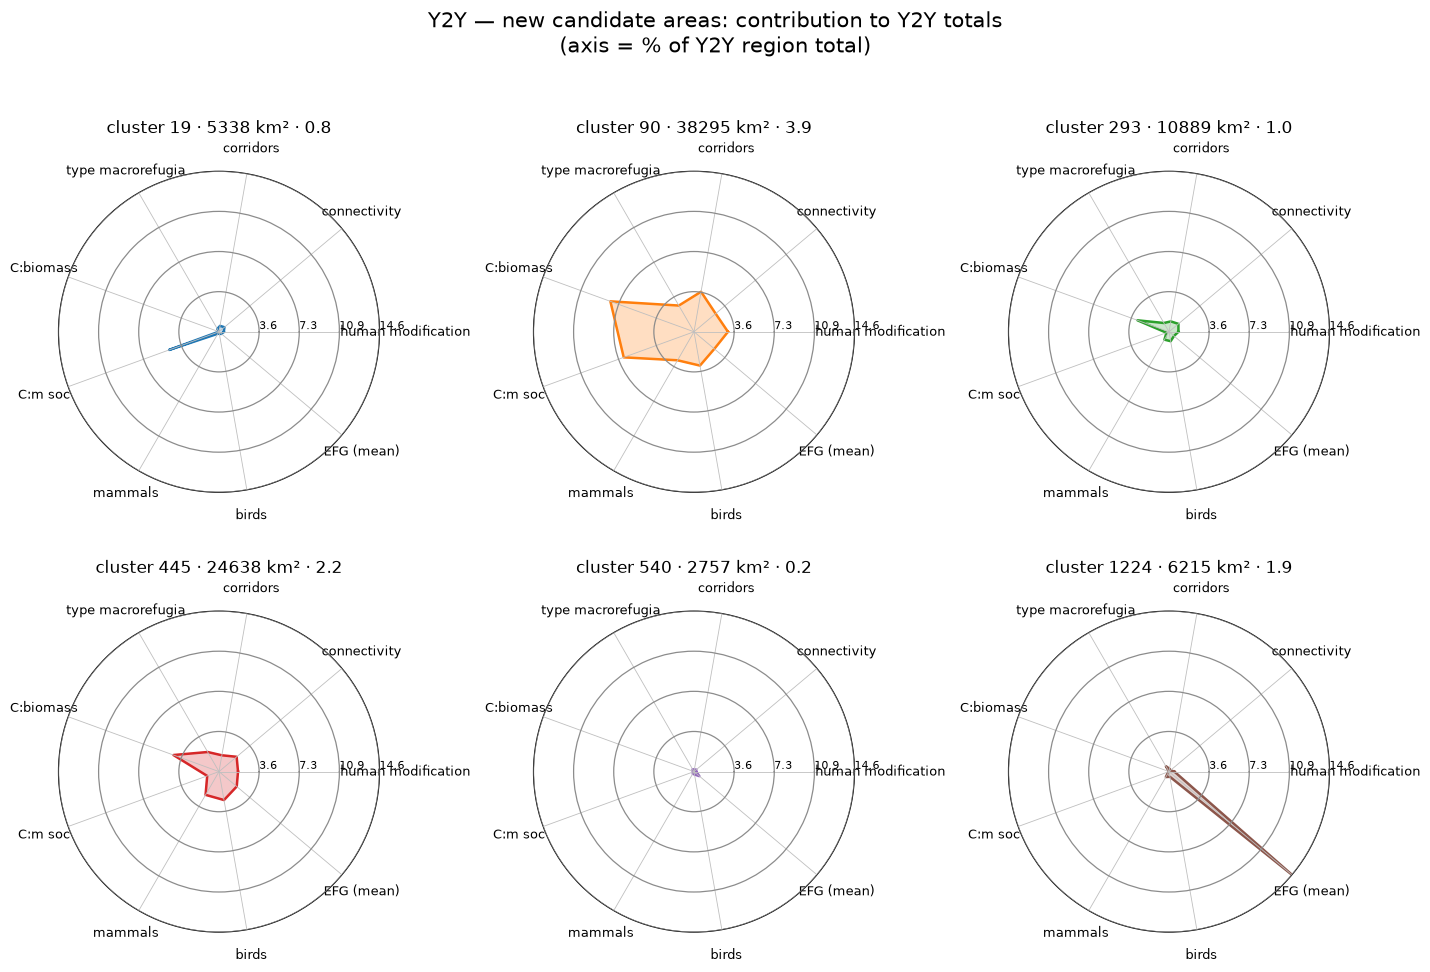

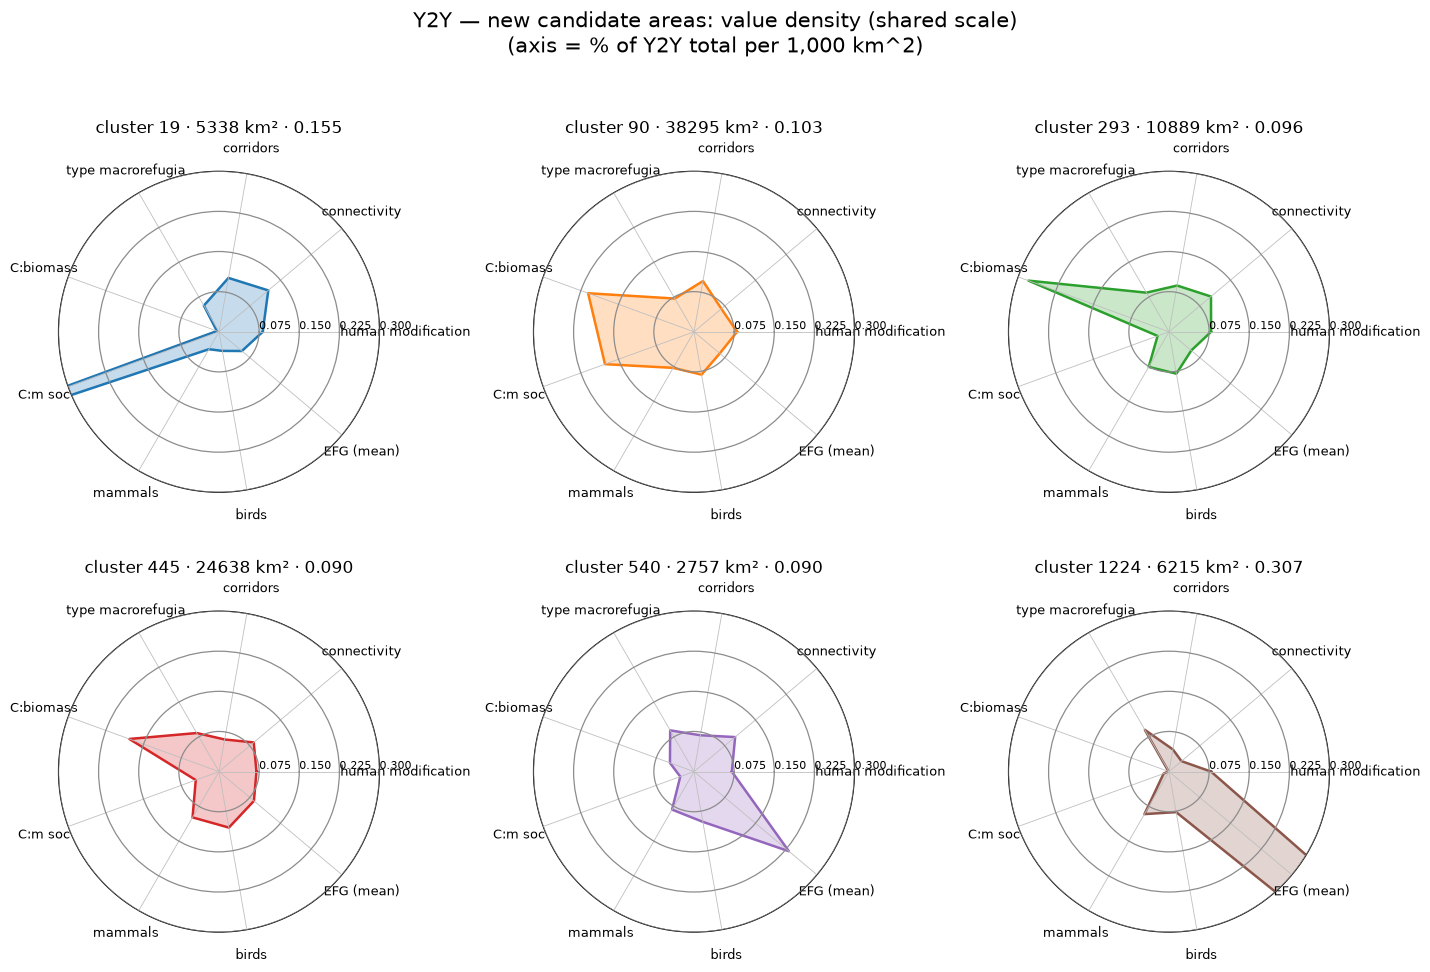

In [9]:
# ---- New candidate areas: 3 star-plot views (richness / contribution / efficiency) ----
rc.new_stars(A)

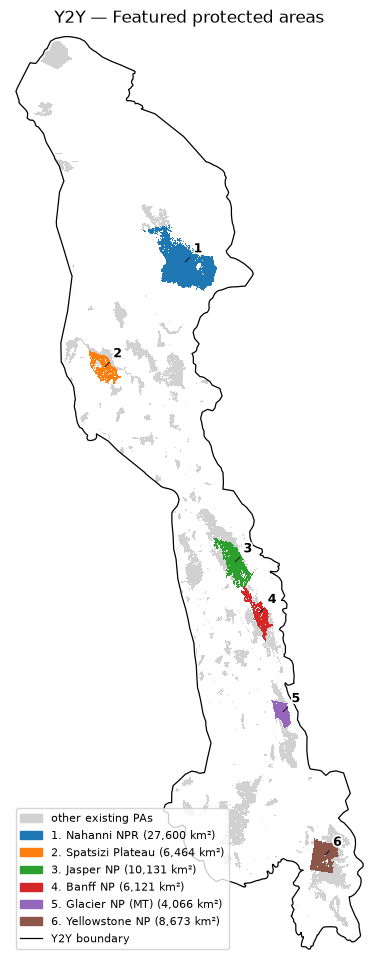

In [10]:
# ---- Benchmark areas: map ----
rc.bench_map(A)

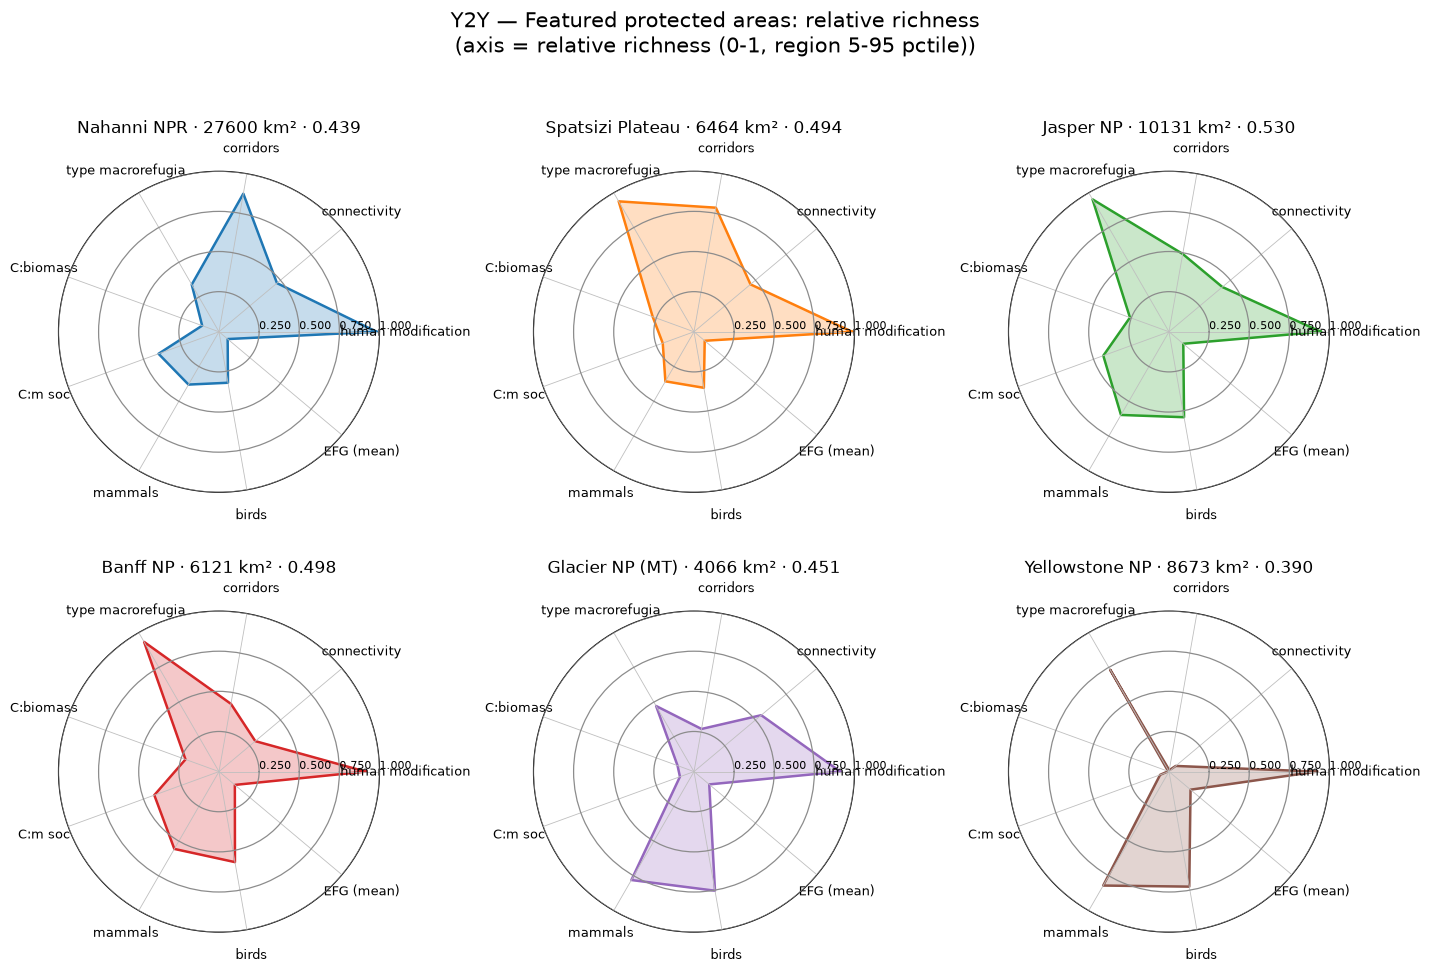

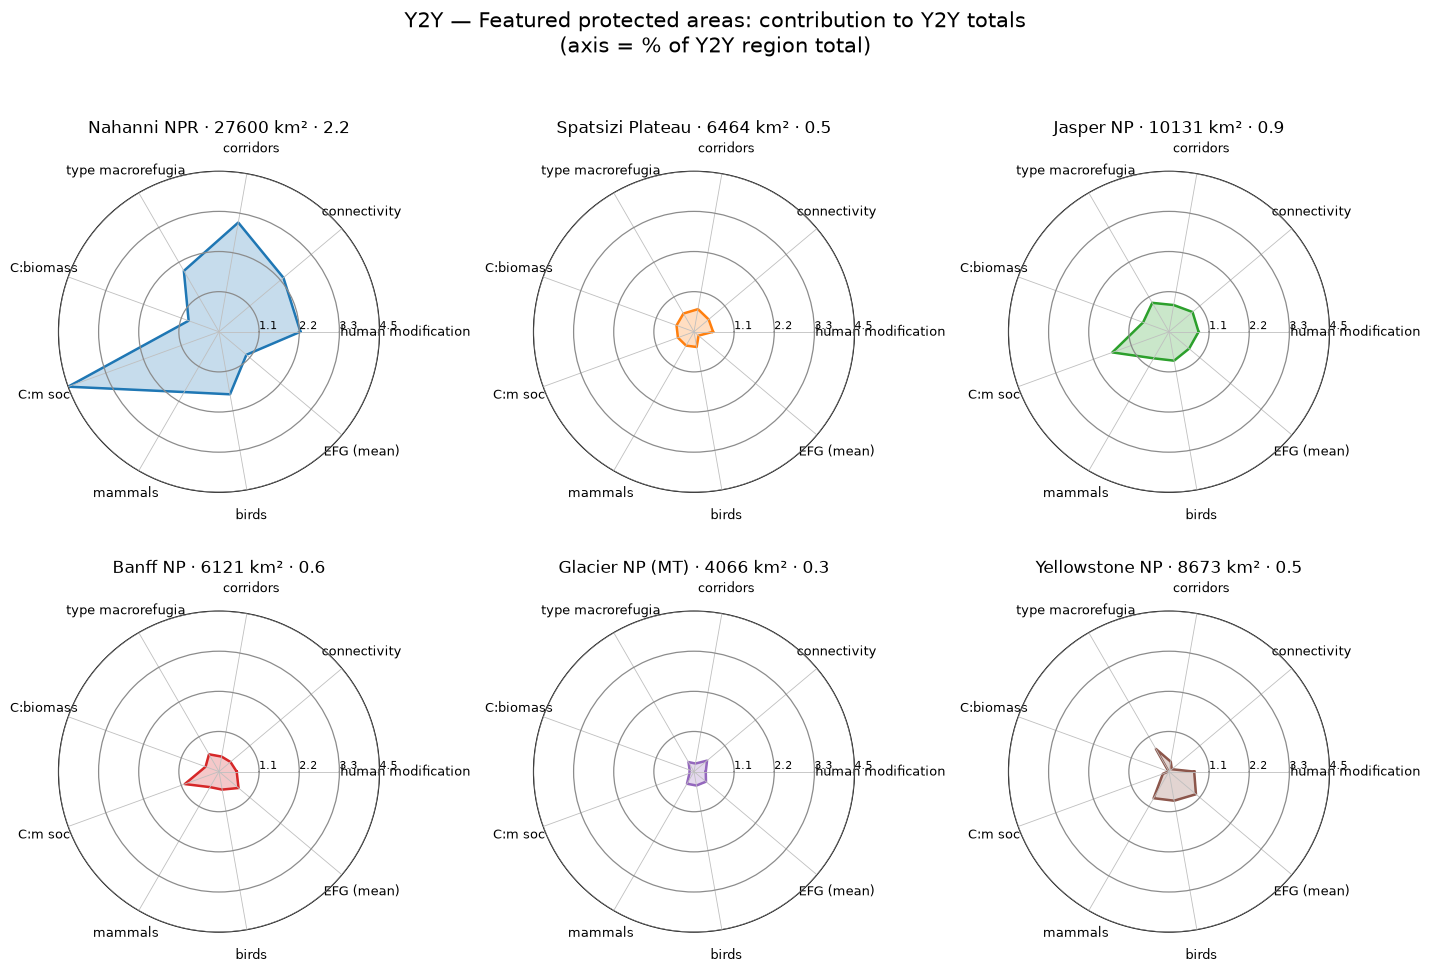

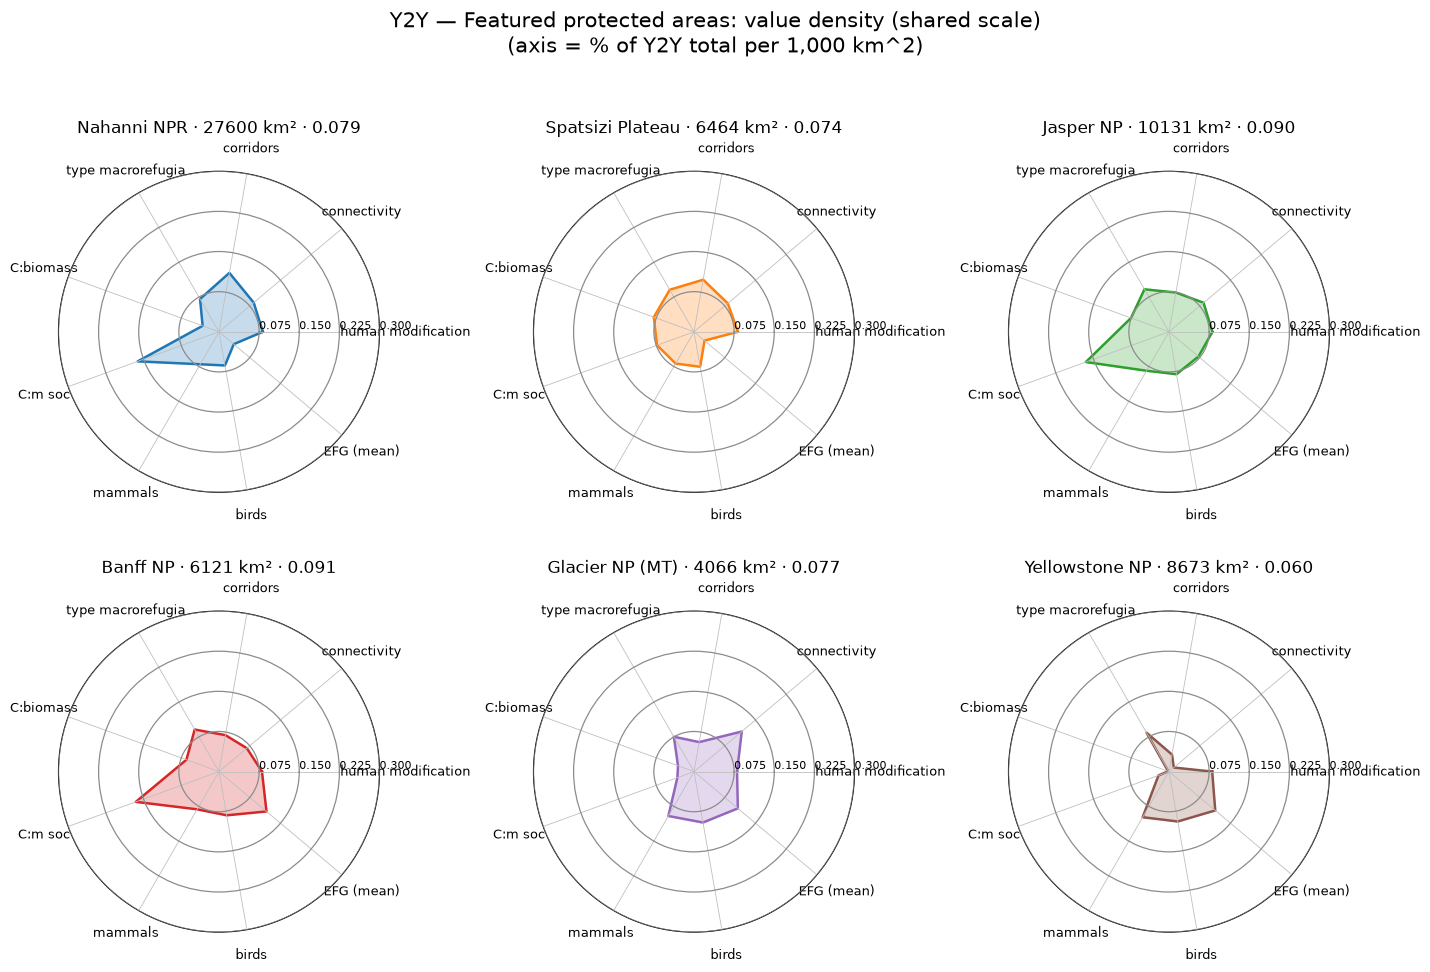

In [11]:
# ---- Benchmark areas: 3 star-plot views ----
rc.bench_stars(A)

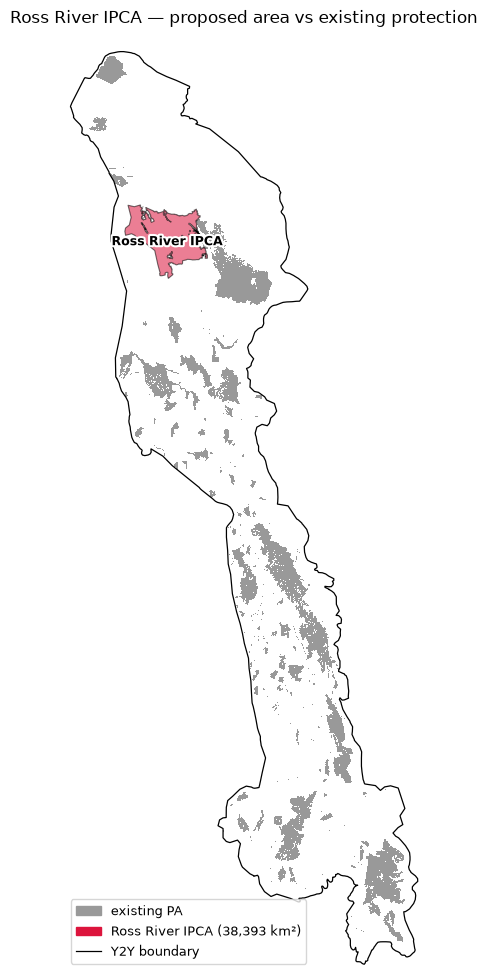

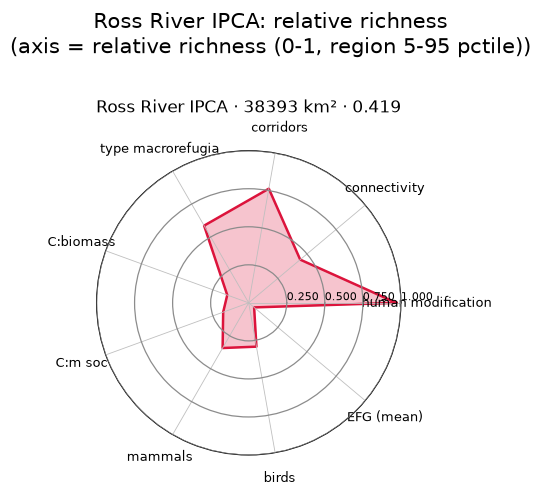

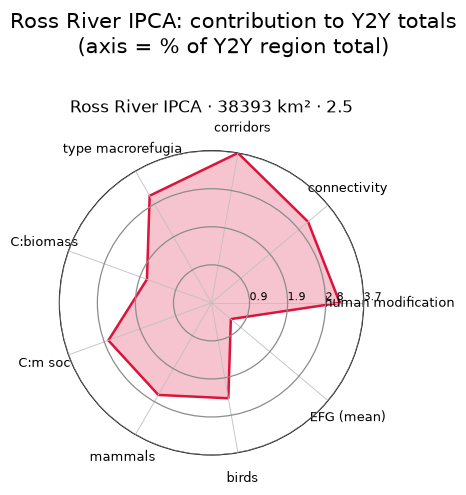

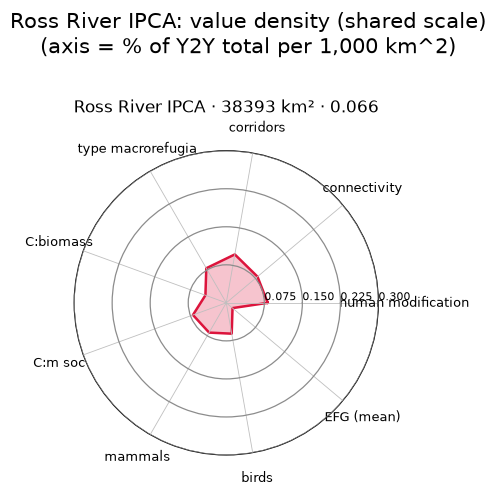

In [12]:
# ---- Manual area (Ross River for y2y; no-op for the sub-regions) ----
rc.manual_block(A)

In [13]:
# ---- Consequences: transposed decision matrices (contribution / efficiency / raw) ----
rc.consequences(A)

CONTRIBUTION (% of Y2Y total):
                                                                                                                           NEW-19    NEW-90   NEW-293   NEW-445  NEW-540  NEW-1224  Nahanni NPR  Spatsizi Plateau  Jasper NP  Banff NP  Glacier NP (MT)  Yellowstone NP  Ross River IPCA
Contribution = area's share of the Y2Y region-wide total per input (%). Rows: 2 area metrics + 9 inputs; columns: areas.                                                                                                                                                                
area (km^2)                                                                                                               5338.00  38295.00  10889.00  24638.00  2757.00   6215.00     27600.00           6464.00    10131.0   6121.00          4066.00         8673.00         38393.00
area (% of Y2Y)                                                                                                              0

(                                                     NEW-19    NEW-90   NEW-293   NEW-445  NEW-540  NEW-1224  Nahanni NPR  Spatsizi Plateau  Jasper NP  Banff NP  Glacier NP (MT)  Yellowstone NP  Ross River IPCA
 Contribution = area's share of the Y2Y region-w...                                                                                                                                                                
 area (km^2)                                         5338.00  38295.00  10889.00  24638.00  2757.00   6215.00     27600.00           6464.00    10131.0   6121.00          4066.00         8673.00         38393.00
 area (% of Y2Y)                                        0.42      3.01      0.86      1.94     0.22      0.49         2.17              0.51        0.8      0.48             0.32            0.68             3.02
 Intactness                                             0.40      3.10      0.90      1.70     0.20      0.50         2.30              0.50        0.8 

In [14]:
# ---- Plain-language strongest / weakest summary per area ----
rc.plain_language(A)

Y2Y — per-area strongest / weakest inputs (by relative richness):

  NEW-19                 strongest: Carbon: mineral soil, Intactness, Climate corridors   |   weakest: Climate refugia, Mammal richness, Carbon: biomass
  NEW-90                 strongest: Intactness, Climate corridors, Carbon: biomass   |   weakest: Ecosystem groups (EFG), Carbon: mineral soil, Climate refugia
  NEW-293                strongest: Intactness, Carbon: biomass, Climate refugia   |   weakest: Carbon: mineral soil, Ecosystem groups (EFG), Mammal richness
  NEW-445                strongest: Bird richness, Mammal richness, Climate refugia   |   weakest: Ecosystem groups (EFG), Carbon: mineral soil, Climate corridors
  NEW-540                strongest: Climate refugia, Bird richness, Mammal richness   |   weakest: Carbon: mineral soil, Ecosystem groups (EFG), Carbon: biomass
  NEW-1224               strongest: Climate refugia, Intactness, Mammal richness   |   weakest: Carbon: biomass, Carbon: mineral soil, Cli

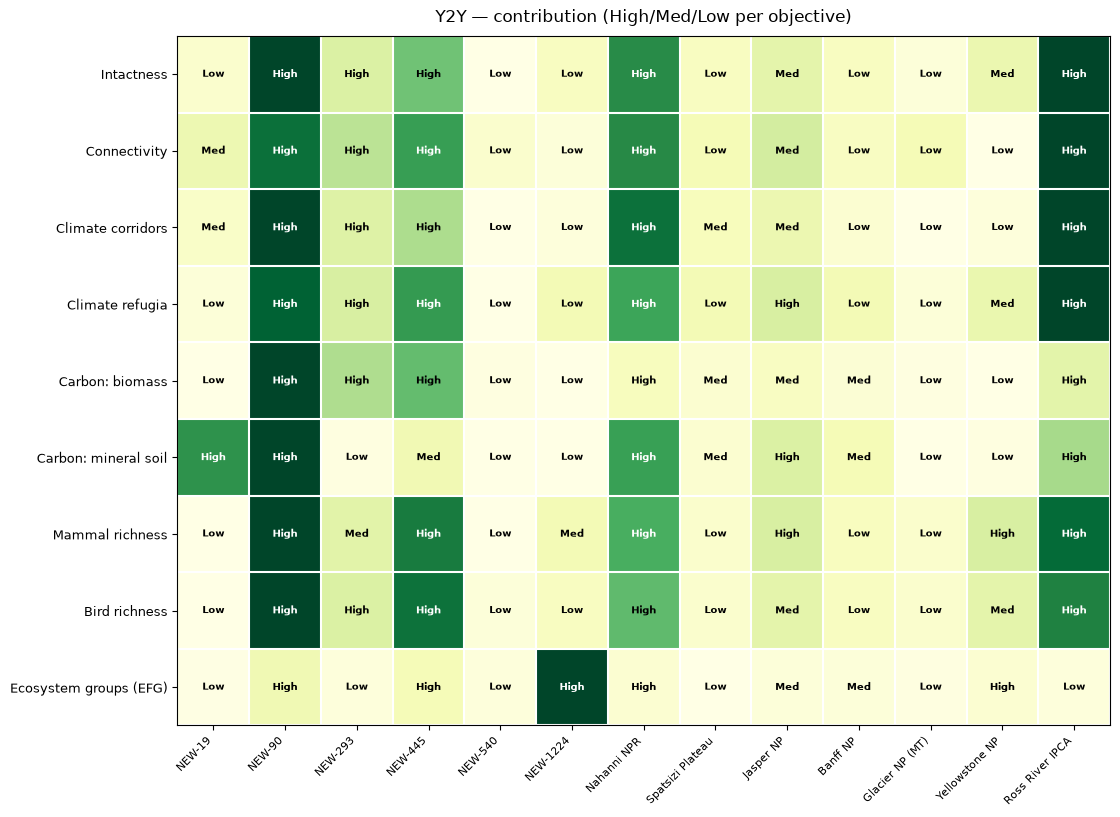

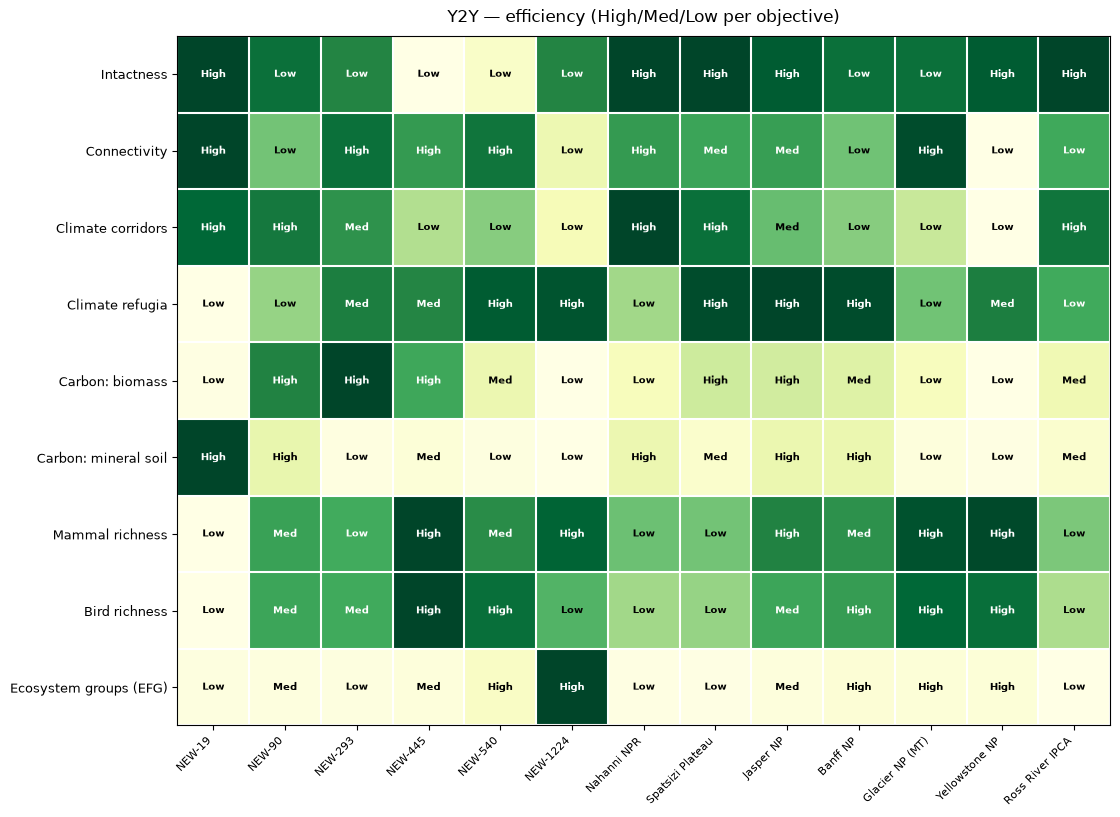

In [15]:
# ---- Colors-only High/Med/Low heatmaps (workshop / accessibility) ----
rc.heatmaps(A)